# 第56篇 | PCA主成分分析：高维数据的压缩与可视化

> 这是「数据分析从入门到精通」系列的第 56 篇。聚类学完了，这篇来学另一个无监督学习利器——PCA 降维。特征太多、维度太高时，可视化困难、模型容易过拟合，PCA 帮你去芜存菁，把高维数据压缩到低维而不丢失主要信息。

嗨，我是小荷～ 今天学一个超级实用的降维技术：**PCA（主成分分析，Principal Component Analysis）**。

---

## 一、为什么需要降维？

我们用相亲来打比方。假设你手里有 100 份相亲对象的资料，每个人都有 20 个不同的指标（维度）：

身高、体重、腰围、臂长、左眼视力、右眼视力、高数成绩、线性代数成绩、Python水平、大舅的职业、二姑的收入、平时几点起床、喜欢吃鲁菜还是粤菜……

面对这 20 个指标，你的相亲大脑已经过载了，根本没办法在脑海里给这 100 个人画个画像（无法可视化）。

你自然会想压缩一下这20个指标，看能否变成2-3个，这样一眼就能看出谁和谁是一类人。这就是降维。

降维是机器学习与数据分析中的一项关键技术，其核心目的是在保留数据主要信息的前提下，减少特征数量，从而提升模型效率、可解释性与可视化能力。它并非简单地“删掉数据”，而是通过**数学变换或特征选择**，将高维空间中的复杂结构映射到低维空间，使数据更易于处理和理解。

**高维数据的痛点**：
- 可视化困难: 人类只能直观理解二维或三维空间。通过降维（如PCA、t-SNE、UMAP），可以将成千上万维的数据投影到2D或3D平面，便于观察数据分布、聚类结构和异常点，辅助业务决策
- 计算量大，训练慢: 在分类、聚类或回归任务中，使用降维后的特征往往能获得更好的效果。例如，主成分分析（PCA）通过保留最大方差方向，线性判别分析（LDA）则最大化类间距离，都能显著提升后续模型的准确率。
- 维度灾难（样本稀疏）: 当特征数量过多时，数据在高维空间中变得稀疏，导致模型训练困难、过拟合风险增加、计算成本飙升
- 噪声多，容易过拟合: 许多特征之间高度相关（如“身高”与“体重”），或包含大量无意义的随机波动

**降维的好处**：
- 数据可视化
- 去除噪声
- 减少存储
- 加速训练

**常见的降维方法**
- 线性方法：如主成分分析（PCA）、线性判别分析（LDA），适用于数据结构相对简单、线性关系明显的情况
- 非线性方法：如t-SNE、UMAP、自编码器，能捕捉复杂的流形结构，更适合高维非欧几里得数据
- 特征选择：直接筛选出最重要的原始特征，而非进行变换，保留可解释性

**代码演示：维度灾难**

下面我们设定了一个初始数据密度10%，来模拟计算一下从 1 维到 20 维时对应的有效区域超体积，再用图表直观展示维度灾难。

这里做几个说明：
1. 代码里的10% 只是一个直观、通用的假设：现实里数据不会均匀填满整个特征空间，只会聚集在每个维度很小的一段范围内，选 10% 是为了方便演示规律，不是固定标准。
2. d 维下有效区域超体积公式：\(V(d) = 0.1^d\)，是个指数函数，底数 \(0.1 < 1\)，维度 d 越大，结果指数级趋近于 0。
3. 因为 \(0.1^d\) 下降太快，普通线性坐标下高维部分会直接贴到横轴，看不出趋势，所以用`plt.semilogy()` 把 Y 轴改成对数刻度，可以清晰展示指数衰减的全过程。

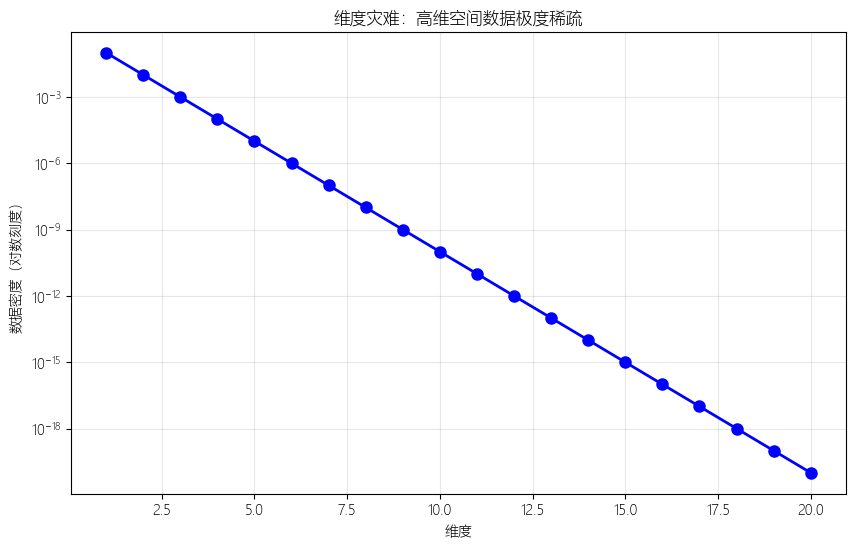

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_iris, make_classification
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 可视化维度灾难
volumes = []

# 循环计算 1~20 维 下的数据密度：公式 0.1^d 模拟高维空间特性
dimensions = range(1, 21)
for d in dimensions:
    # 单位超立方体的体积随维度指数下降
    # 维度 d 越大，结果指数级趋近于 0
    volume = 0.1 ** d  # 假设10%的数据密度
    volumes.append(volume)

plt.figure(figsize=(10, 6))
plt.semilogy(dimensions, volumes, 'bo-', linewidth=2, markersize=8)  # 对数刻度
plt.xlabel('维度')
plt.ylabel('数据密度（对数刻度）')
plt.title('维度灾难：高维空间数据极度稀疏')
plt.grid(True, alpha=0.3)
plt.show()


可以看到，随着维度的升高，高维空间中的数据变得极度稀疏。

---

## 二、PCA到底在做什么？

前面你相亲面对这20个指标挑花眼了，正愁怎么降维呢，PCA就是帮你做这场“信息浓缩”的专家。

它会这么做：

**2.1 寻找第一主成分：合并“高度相关的废话”**

PCA 扫描这 20 个指标，它敏锐地发现了有一些指标**高度相关，都在表达同一件事**：

* “身高、体重、腰围、臂长”：其实都在说这人的“体型”。
* “高数成绩、线性代数成绩、Python水平”：其实都在说这人的“理科逻辑能力”。

PCA 开始发挥它的数学魔力。它发现，如果你把“身高、体重、腰围”按一定比例揉在一起，变成一个叫“体型指数”的新指标，这个新指标散得最开（方差最大），最能拉开这 100 个人的差距。

这就叫**第一主成分（PC1）**。它把原本零散的四五个体型指标，浓缩成了一个含金量最高的新指标。

**2.2 寻找第二主成分：寻找全新方向的信息**

找到了“体型指数”后，PCA 还要找第二个指标，但有一个硬性条件：**第二个指标和第一个指标必须毫无关系（数学上叫正交/垂直）**。因为如果还有关系，就说明信息重叠了。

既然“体型”已经确定了，PCA 就在剩下的指标里继续找。它发现“高数、线代、Python”这几项揉在一起，变成一个叫“智商/逻辑指数”的新指标，最能拉开剩下的差距。

这就是**第二主成分（PC2）**。它和体型完全无关，带来了全新的、最大的信息量。

**2.3 扔掉“噪音”和“废话”**

剩下的指标呢？比如“左眼视力”和“右眼视力”，虽然它们也相关，但对区分一个人合不合适相亲，信息量太小了；还有“平时几点起床”，大家都差不多，根本拉不开差距。

PCA 掐指一算：**“体型指数（PC1）”和“逻辑指数（PC2）”已经保留了原本 20 个指标中 85% 的有用信息。**

剩下的那些视力、大舅职业等琐碎指标，加起来也无足轻重，PCA 直接大手一挥：**全部扔掉！**

**2.4 最终效果**

现在，20 列的复杂表格，变成了只有 2 列的精简表格：

1. **横轴（X轴）**：体型指数（从骨感变丰满）
2. **纵轴（Y轴）**：逻辑指数（从文艺到硬核学霸）

你把这 100 个相亲对象往这个 2D 图上一画：

- 右上角那一堆：身材高大魁梧的硬核程序员。
- 左下角那一堆：身材娇小、偏向文科的文艺青年。

你一眼就能看清大局，这就是 PCA 降维和可视化的魅力。

**2.5 PCA 的唯一大缺点：失去“可解释性”**
这是 PCA 最让人头疼的地方：它把原本有意义的名字弄丢了。

- 降维前，表格的列名很明确：身高、体重、年龄、收入。

- PCA 降维后，合并出了三个新列，名字变成了：主成分1、主成分2、主成分3。

相亲挑完后，你指着图上最右上角的一个点对媒婆说：“我就要这个‘体型指数 9.5，逻辑指数 8.8’的人！”
媒婆一脸懵圈问你：“那他到底是高还是胖？他 Python 到底考了多少分？”

你回答不出来。因为 9.5 已经是身高体重混合后的产物了，你再也无法单独拆出他具体的 constitutive 维度（身高是多少厘米）了。 这就是 PCA 失去“字面可解释性”的代价。


**2.6 标准计算步骤**
1. **对数据进行中心化（数据归零）处理**
   - 具体做法：算出每一列（每个特征）的平均值，然后让这列里的所有数字都减去这个平均值。
   - 目的：让数据的中心点完美的坐标变成 $(0, 0)$。这样做不会改变数据点之间的相对位置和分布形状，但是能让后面的数学计算变得非常简单。
2. **计算协方差矩阵（寻找两两之间的暧昧关系）**
   - 具体做法：通过数学公式，算出一个协方差矩阵（Covariance Matrix）。
      - 如果身高变大，体重也跟着变大，它们俩的协方差就是正数（说明信息高度重叠）。
      - 如果一个指标变大，另一个变小，就是负数。
   - 目的：这个矩阵就像是一张“关系网”，里面精确记录了数据在各个方向上的散布程度（方差），以及指标之间的相关性。
3. **对协方差矩阵进行特征值分解（找出“骨架”和“含金量”）**
   这是 PCA 最核心、最魔幻的一步。我们要对刚才那个协方差矩阵进行特征值分解（或者使用更高级的 SVD 奇异值分解）。经过这一步，我们会解出两样东西：
   - 特征向量（Eigenvectors）：它们代表了数据分布的新方向。这些向量互相垂直，对应 PCA 里互不相关的新特征，指向数据拉得最长、最分散的那些“骨架”轴。
   - 特征值（Eigenvalues）：它们代表了每个新方向的含金量（方差大小）。特征值越大，说明这个方向涵盖的信息量越多。
4. **特征值排序并选择主成分（保留精华，砍掉糟粕）**
   - 具体做法：
      - 把特征值从大到小排序。最大的特征值对应的方向就是 第一主成分（PC1），第二大的就是 第二主成分（PC2）。
      - 计算贡献率：比如 $PC1$ 的特征值除以所有特征值的和，发现它等于 $90\%$。这就意味着，光是 $PC1$ 这一个方向，就已经亲下了原本数据中 $90\%$ 的信息量！
      - 根据降维需求（比如你想降到 1 维，或者要求保留 $95\%$ 的信息），只留下前 $k$ 个主成分，剩下的方向直接丢弃。
5. **投影转换（生成新数据）**
    - 具体做法：用原本去中心化后的旧数据，去乘以你筛选出来的这几个主成分的特征向量。
    - 最终结果：原本的 [身高, 体重] 两列数据，通过数学转换，变成了一列全新的、综合了身高体重的坐标值：[主成分1]。降维圆满完成！

**2.7 代码演示：手动计算特征值**
下面我们来手动复现 PCA 核心数学流程，用一组二维强相关数据演示 PCA 原理，完整走完【数据构造→中心化→协方差矩阵→特征分解→排序主成分】全步骤。

重点说一下3个函数：
1. `np.random.multivariate_normal(mean, cov, 300)`
   - mean: 多维分布的均值向量,  mean = [0, 0]：两个特征的均值都为 0。
   - cov: 协方差矩阵, 控制单个特征自身的方差（数据离散程度）和 两个特征之间的协方差（相关性强弱）
3. `np.cov(X_centered.T)`： 计算协方差矩阵，默认一行是一个“特征”，但我们的原始数据是列才是特征，所以要转置
4. `np.linalg.eig(cov_matrix)`
   - 功能： 对协方差矩阵做特征分解，分解后得到新的投影方向，这是 PCA 的核心数学步骤。具体怎么求，线性代数里的行列式方程和齐次方程组，你还记得吗？😄
   - 返回值：2个，特征值 eigenvalues 和 特征向量 eigenvectors

In [14]:
print("\nPCA演示:")
print("=" * 60)

# 设置随机种子，保证每次生成的数据一致
np.random.seed(42)
# 设定二维数据的均值，两个特征均值都为0
mean = [0, 0]
# 协方差矩阵：非对角元素不为0，代表两个特征**强线性相关**
cov = [[2, 1.8], [1.8, 2]]  
# 生成300个二维样本，构造一组存在相关性的数据集
X_2d = np.random.multivariate_normal(mean, cov, 300)

# ===================== 手动实现PCA核心步骤 =====================
# 1. 数据中心化：每个特征减去自身均值，把数据整体平移到原点
# PCA标准前置步骤，消除均值对协方差计算的影响
X_centered = X_2d - X_2d.mean(axis=0)

# 2. 计算协方差矩阵
# .T 矩阵转置，np.cov要求行为特征、列为样本
cov_matrix = np.cov(X_centered.T)
print(f"协方差矩阵:\n{cov_matrix}")

# 3. 对协方差矩阵做特征值分解
# np.linalg.eig(A) 是 NumPy 线性代数工具，对方阵做特征值分解
# 得到：特征值(代表信息量大小)、特征向量(代表新坐标轴方向)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix) 
print(f"\n特征值: {eigenvalues}")
print(f"特征向量:\n{eigenvectors}")

# 4. 对特征值从大到小排序，对应重新排列特征向量
# argsort() 默认升序，[::-1] 反转变为降序
idx = eigenvalues.argsort()[::-1]
# 按排序后的索引，重排特征值
eigenvalues = eigenvalues[idx]
# 特征向量列与特征值一一对应，同步重排
eigenvectors = eigenvectors[:, idx]

print(f"\n排序后特征值: {eigenvalues}")
# 计算每个主成分的方差解释率：单个特征值 / 所有特征值总和
# 直观对比两个主成分的信息权重
# 数值越大，代表该方向承载的原始数据信息越多
print(f"单个主成分的方差解释率: {eigenvalues / eigenvalues.sum()}")


PCA核心思想演示:
协方差矩阵:
[[1.9267468  1.72864794]
 [1.72864794 1.90433377]]

特征值: [3.64422455 0.18685601]
特征向量:
[[ 0.70939505 -0.70481108]
 [ 0.70481108  0.70939505]]

排序后特征值: [3.64422455 0.18685601]
解释方差比例: [0.95122629 0.04877371]


特征值算出来了，我们来画三张图，**把 PCA 的降维过程可视化出来**：
1. 原始二维强相关数据分布
2. 中心化后的数据，用红色箭头标出两个主成分方向，箭头长度代表数据波动大小，并标注各自信息占比
3. 通过矩阵运算，将数据投影到主成分新坐标系，消除原特征的相关性

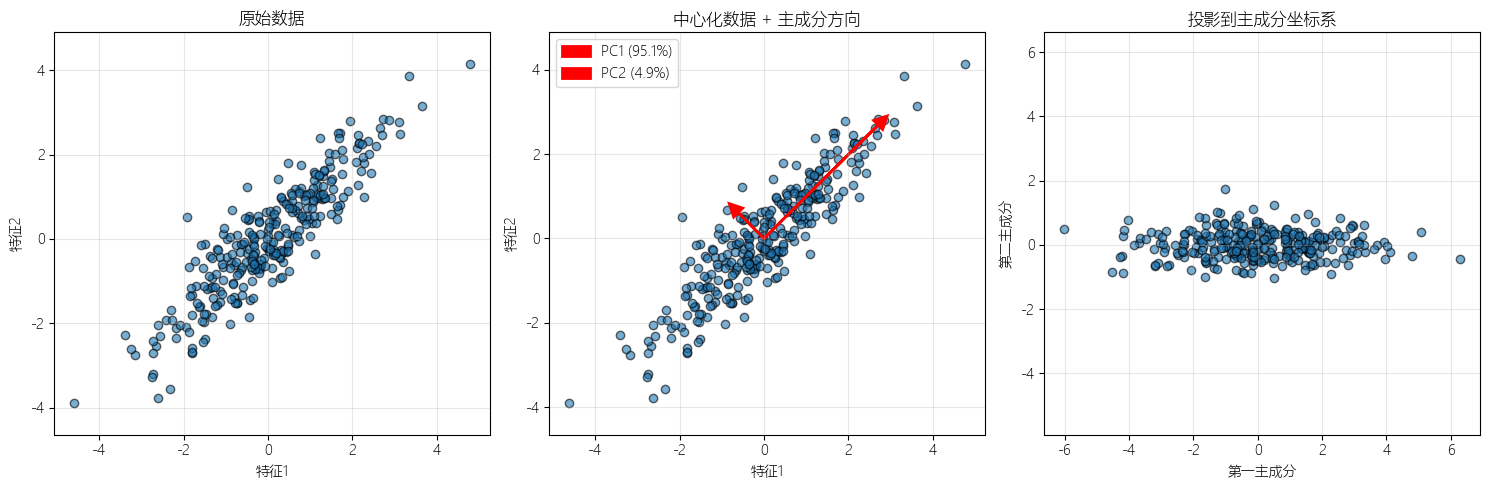


从上图可以看出:
- 第一主成分（PC1）捕捉了数据变化最大的方向
- 第二主成分（PC2）与PC1正交，捕捉剩余变化
- 投影后数据在新坐标系下不再相关


In [15]:
# 创建画布：1行3列子图，整体尺寸 15×5
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ========== 第一张图：原始二维数据 ==========
# 绘制原始散点图，设置透明度、描边
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, edgecolors='k')
axes[0].set_title('原始数据')       # 子图标题
axes[0].set_xlabel('特征1')        # X轴标签
axes[0].set_ylabel('特征2')        # Y轴标签
axes[0].grid(True, alpha=0.3)      # 显示网格，透明度0.3
axes[0].axis('equal')              # 横纵轴等比例，防止图形拉伸变形

# ========== 第二张图：中心化数据 + 绘制两个主成分方向 ==========
# 绘制中心化后的数据（整体平移到坐标原点）
axes[1].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6, edgecolors='k')

# 循环遍历2个主成分（2组特征向量/特征值）
for i in range(2):
    # 缩放特征向量：用 根号特征值 控制箭头长度，再整体放大2倍方便观察
    # 根号特征值对应标准差，直观体现该方向数据波动大小
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2
    
    # 从原点(0,0)绘制箭头，代表主成分方向
    axes[1].arrow(
        0, 0, vec[0], vec[1],
        head_width=0.3,    # 箭头宽度
        head_length=0.3,   # 箭头头部长度
        fc='red', ec='red',# 箭头填充色、轮廓色
        linewidth=2,
        # 图例：标注主成分序号 + 方差解释占比
        label=f'PC{i+1} ({eigenvalues[i]/eigenvalues.sum():.1%})'
    )

axes[1].set_title('中心化数据 + 主成分方向')
axes[1].set_xlabel('特征1')
axes[1].set_ylabel('特征2')
axes[1].legend()        # 显示图例
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')   # 等比例坐标轴

# ========== 第三张图：数据投影到新主成分坐标系 ==========
# 矩阵乘法 @ ：中心化数据 × 特征向量矩阵，完成坐标变换（全量投影，暂未降维）
X_pca_manual = X_centered @ eigenvectors

# 绘制投影后的数据分布
axes[2].scatter(X_pca_manual[:, 0], X_pca_manual[:, 1], alpha=0.6, edgecolors='k')
axes[2].set_title('投影到主成分坐标系')
axes[2].set_xlabel('第一主成分')
axes[2].set_ylabel('第二主成分')
axes[2].grid(True, alpha=0.3)
axes[2].axis('equal')

# 自动调整子图间距，避免重叠
plt.tight_layout()
# 展示整张画布
plt.show()

# 图表结论解读
print("\n从上图可以看出:")
print("- 第一主成分（PC1）捕捉了数据变化最大的方向")
print("- 第二主成分（PC2）与PC1正交，捕捉剩余变化")
print("- 投影后数据在新坐标系下不再相关")

---

## 三、Scikit-learn里的PCA

下面我们直接调用官方 PCA 工具，把它输出的核心指标跟上一步手动特征分解算出的指标做个对比。

In [7]:
# 使用sklearn的PCA
pca = PCA()
X_pca = pca.fit_transform(X_2d)

print(f"\nSklearn PCA结果:")
print("-" * 40)
print(f"解释方差比例: {pca.explained_variance_ratio_}")
print(f"累计解释方差: {np.cumsum(pca.explained_variance_ratio_)}")
print(f"主成分方向:\n{pca.components_}")

# 对比手动计算和sklearn结果
print(f"\n手动计算 vs Sklearn:")
print(f"手动特征值: {eigenvalues / eigenvalues.sum()}")
print(f"Sklearn解释方差: {pca.explained_variance_ratio_}")



Sklearn PCA结果:
----------------------------------------
解释方差比例: [0.95122629 0.04877371]
累计解释方差: [0.95122629 1.        ]
主成分方向:
[[ 0.70939505  0.70481108]
 [-0.70481108  0.70939505]]

手动计算 vs Sklearn:
手动特征值: [0.95122629 0.04877371]
Sklearn解释方差: [0.95122629 0.04877371]


可以看到两种方法得出的解释方差是一样的。

---

## 四、确定保留多少主成分

降维降多少？保留太少丢信息，保留太多没意义。在主成分分析（PCA）中，确定保留多少个主成分是一个需要综合考量多个标准和实际应用场景的过程。以下是几种常用的核心方法：

**4.1 累计方差贡献率（最常用标准）**

累积贡献率反映了所选主成分对原始数据集变异性的解释程度。通常，选择累积贡献率达到一定阈值的主成分个数为宜。
- 常规阈值：一般建议保留累积方差贡献率在 70%~90% 之间的主成分。
- 更高要求：在某些场景下，为了保留更多核心信息，也会选择累积贡献率达到 85%~95% 的主成分。

**4.2 特征值准则（Kaiser准则）**
  
特征值代表了该主成分表征的数据变异量（解释的方差量）。
- 核心原则：通常只保留特征值大于 1 的主成分。
- 原因：对于标准化后的数据，每个原始变量引入的变异性为 1。如果某个主成分的特征值小于 1，说明它解释的变异性还不如单个原始变量，因此可以将其剔除。

**4.3 碎石图检验（Scree Plot）**
  
碎石图是一种将特征值从大到小呈现的折线图，用于直观判断主成分的重要性。
判断方法：折线图的前一部分通常下降较快，而后部分趋于平缓，整体呈现为一个“肘部”的形状。
决策依据：保留“肘部”（拐点）之前的主成分，因为在此点之后添加更多主成分对解释方差的贡献将变得微乎其微。

**4.4 指定固定维度（业务 / 场景驱动）**

根据下游任务硬性规定维度：
- 二维 / 三维可视化：直接设 n_components=2 或 3
- 配合模型输入要求、算力限制，人为指定维度

| 方法 | 用法 | 优点 | 缺点 | 适用场景 |
| --- | --- | --- | --- | --- |
| 累计方差阈值 | 设 80%/90%/95% | 标准、可量化、统一规范 | 阈值靠经验 | 绝大多数机器学习任务（首选） |
| 特征值 > 1 （Kaiser准则）| 统计规则 | 纯数学标准 | 不一定适配业务 | 传统统计分析 |
| 手肘 / 碎石图 | 看曲线拐点 | 直观、贴合数据分布 | 主观，无统一标准 | 数据分析、报告展示 |
| 固定维度 | 直接指定 2/3/10 维 | 简单可控 | 不考虑信息保留率 | 数据可视化、接口维度限制 |

**4.5 代码演示：累计方差阈值法**

下面的代码提供了一个标准的“PCA 降维维度选择工作流”。它通过计算和可视化累计方差解释率，帮助我们在“保留足够信息”和“最大程度降维”之间找到最佳平衡点，从而避免盲目选择降维维度。
1. 数据预处理与 PCA 拟合： 初始化 PCA 时不指定降维维度（保留全部 64 个主成分），对标准化后的数据进行拟合与变换，以便后续分析每个主成分的信息贡献度。
2. 双图可视化评估信息保留率
   - 左图（各主成分方差解释率）：使用柱状图展示了前 20 个主成分各自捕获的信息比例。这能帮助我们看到哪些主成分是“核心”，哪些是“次要”的（通常前几个主成分占据了绝大部分方差）。
   - 右图（累计方差解释率曲线）：绘制了随着主成分数量增加，信息保留比例的累积曲线。同时，代码在图上标记了 80%、90%、95% 三条常用的信息保留阈值线，并画出了对应的垂直虚线，直观地指出了达到这些阈值所需的主成分数量。
3. 量化输出与压缩效果评估
   - 计算目标维度：通过代码自动计算出首次达到 80%、90%、95% 累计方差解释率所需的主成分个数（n_80, n_90, n_95）。
   - 评估压缩收益：在控制台打印出不同信息保留标准下，原始 64 维数据可以被压缩到多少维，以及具体的压缩率。

手写数字数据:
  样本数: 1797
  特征维度: 64 (8x8图像)
  类别数: 10


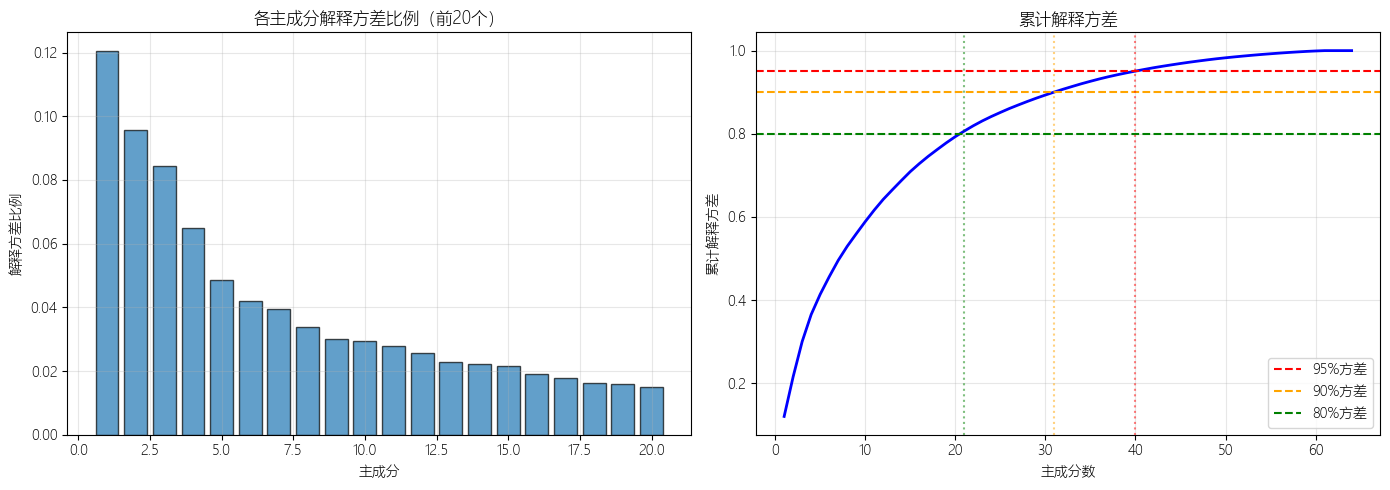


保留方差所需主成分数:
----------------------------------------
保留80%方差: 需要21个主成分 (32.8%)
保留90%方差: 需要31个主成分 (48.4%)
保留95%方差: 需要40个主成分 (62.5%)

维度压缩效果:
  原始维度: 64
  压缩到31维，信息保留90%，压缩率51.6%


In [16]:
# 加载sklearn内置手写数字数据集（8×8像素灰度图）
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

# 打印数据集基本信息
print(f"手写数字数据:")
print(f"  样本数: {X_digits.shape[0]}")       # 样本总数量
print(f"  特征维度: {X_digits.shape[1]} (8x8图像)") # 单张图像展平为64维特征
print(f"  类别数: {len(np.unique(y_digits))}")    # 数字0~9，共10个类别

# 数据标准化：PCA对量纲敏感，先统一特征尺度
X_digits_scaled = StandardScaler().fit_transform(X_digits)

# 初始化PCA，不指定降维维度，默认保留全部64个主成分
pca_digits = PCA()
# 执行PCA变换，得到投影后的数据
X_digits_pca = pca_digits.fit_transform(X_digits_scaled)

# 创建画布，尺寸14×5
plt.figure(figsize=(14, 5))

# ========== 左图：单个主成分方差解释率（前20个） ==========
plt.subplot(1, 2, 1)
# 柱状图展示前20个主成分各自的信息占比
plt.bar(range(1, 21), pca_digits.explained_variance_ratio_[:20], 
        alpha=0.7, edgecolor='black')
plt.xlabel('主成分')
plt.ylabel('解释方差比例')
plt.title('各主成分解释方差比例（前20个）')
plt.grid(True, alpha=0.3)

# ========== 右图：累计方差解释率曲线 ==========
plt.subplot(1, 2, 2)
# 计算累计方差解释率：逐个累加每个主成分的信息占比
cumsum_var = np.cumsum(pca_digits.explained_variance_ratio_)
# 绘制累计曲线
plt.plot(range(1, len(cumsum_var)+1), cumsum_var, 'b-', linewidth=2)

# 画三条水平虚线，标记常用信息保留阈值：80%/90%/95%
plt.axhline(y=0.95, color='r', linestyle='--', label='95%方差')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90%方差')
plt.axhline(y=0.80, color='g', linestyle='--', label='80%方差')

# 找到首次达到对应阈值的主成分个数（+1修正索引从0开始的问题）
n_80 = np.argmax(cumsum_var >= 0.80) + 1
n_90 = np.argmax(cumsum_var >= 0.90) + 1
n_95 = np.argmax(cumsum_var >= 0.95) + 1

# 画垂直虚线，标出对应需要的主成分数量
plt.axvline(x=n_80, color='g', linestyle=':', alpha=0.5)
plt.axvline(x=n_90, color='orange', linestyle=':', alpha=0.5)
plt.axvline(x=n_95, color='r', linestyle=':', alpha=0.5)

plt.xlabel('主成分数')
plt.ylabel('累计解释方差')
plt.title('累计解释方差')
plt.legend()
plt.grid(True, alpha=0.3)

# 自动调整子图间距
plt.tight_layout()
# 展示图像
plt.show()

# 打印不同信息保留率对应的主成分数量、维度压缩效果
print(f"\n保留方差所需主成分数:")
print("-" * 40)
print(f"保留80%方差: 需要{n_80}个主成分 ({n_80/64:.1%})")
print(f"保留90%方差: 需要{n_90}个主成分 ({n_90/64:.1%})")
print(f"保留95%方差: 需要{n_95}个主成分 ({n_95/64:.1%})")

print(f"\n维度压缩效果:")
print(f"  原始维度: 64")
print(f"  压缩到{n_90}维，信息保留90%，压缩率{1-n_90/64:.1%}")

---

## 五、PCA用于数据可视化

下面我们用代码演示使用 PCA 将高维的手写数字数据集（64维）投影到二维平面进行可视化，并评估其降维效果。
1. 降维执行与信息评估
   - 降维操作：通过 PCA(n_components=2) 将标准化后的 64 维数据降至 2 维。
   - 信息保留率：代码打印了降维后的维度以及前两个主成分累计保留的方差比例。这直观地反映了从 64 维压缩到 2 维时，数据核心信息的保留程度。
2. 二维散点图可视化
   - 空间投影：绘制降维后的二维散点图，X 轴和 Y 轴分别代表第一和第二主成分，并在坐标轴标签上标注了它们各自解释的方差比例。
   - 类别着色：通过 c=y_digits 和 cmap='tab10' 为 10 个不同的数字类别分配了不同的颜色，并添加了颜色条（colorbar）作为图例，使数据分布一目了然。


PCA降维到2D:
----------------------------------------
原始维度: 64
降维后维度: 2
保留方差比例: 21.59%


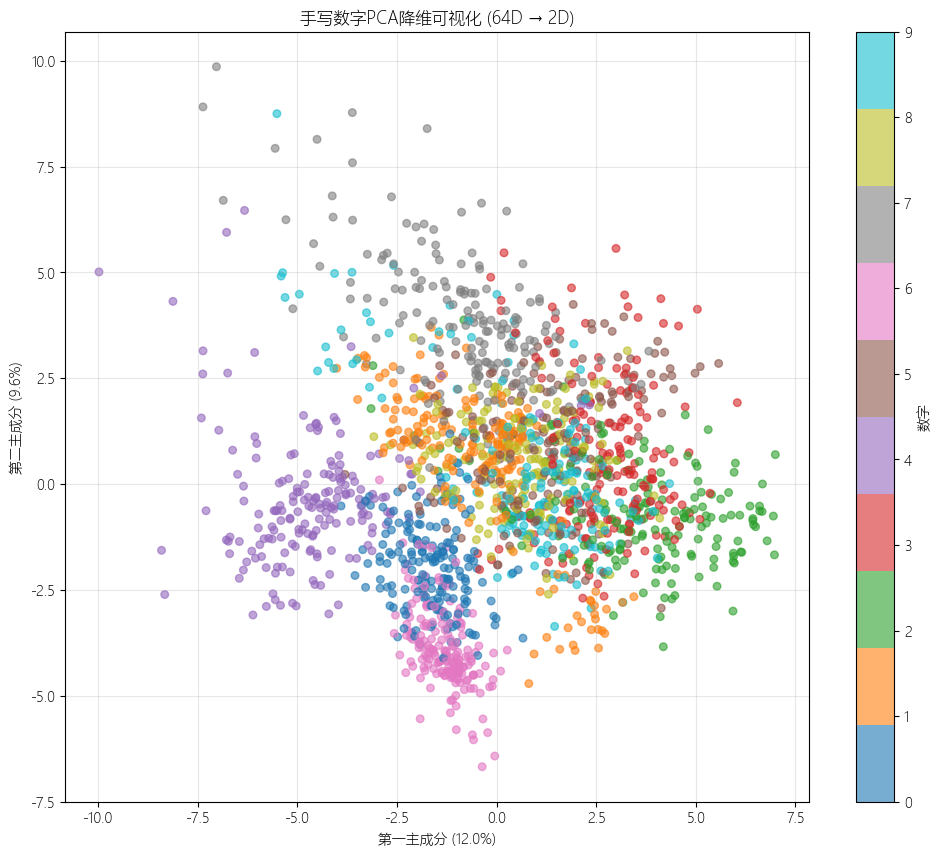

In [17]:
# 用PCA将64维降到2维进行可视化
pca_2d = PCA(n_components=2)
X_digits_2d = pca_2d.fit_transform(X_digits_scaled)

print(f"\nPCA降维到2D:")
print("-" * 40)
print(f"原始维度: {X_digits.shape[1]}")
print(f"降维后维度: {X_digits_2d.shape[1]}")
print(f"保留方差比例: {pca_2d.explained_variance_ratio_.sum():.2%}")

# 可视化
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_digits_2d[:, 0], X_digits_2d[:, 1], 
                     c=y_digits, cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='数字')
plt.xlabel(f'第一主成分 ({pca_2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'第二主成分 ({pca_2d.explained_variance_ratio_[1]:.1%})')
plt.title('手写数字PCA降维可视化 (64D → 2D)')
plt.grid(True, alpha=0.3)
plt.show()

**图片解读：**

尽管只保留了两个主成分，相同数字的样本点在二维空间中依然呈现出明显的聚集趋势，且不同数字之间具备了一定的边界。这证明了 PCA 在大幅压缩数据维度的同时，成功保留了数据的关键拓扑结构。

---

## 六、PCA用于去噪

信号通常具有结构性（集中在少数主成分），而噪声通常是随机且无结构的（分散在次要成分中）。

下面我们演示利用PCA对图像数据进行去噪处理：
1. 模拟数据污染（添加噪声）：给手写数字图像叠加高斯噪声，模拟真实场景的干扰
2. PCA 降维与重构（核心去噪机制）：
   - 降维过滤：PCA(n_components=0.90)，仅保留能够解释 90% 方差的主成分
   - 逆转换重构：通过 inverse_transform 将降维后的低维数据重新映射回原始的 64 维空间
4. 画三行图对比可视化：
   - 第一行（原始）：清晰、干净的手写数字。
   - 第二行（加噪）：布满噪点、细节被破坏的图像。
   - 第三行（去噪）：经过 PCA 重构后的图像，噪点被有效抹除，数字轮廓重新变得清晰。

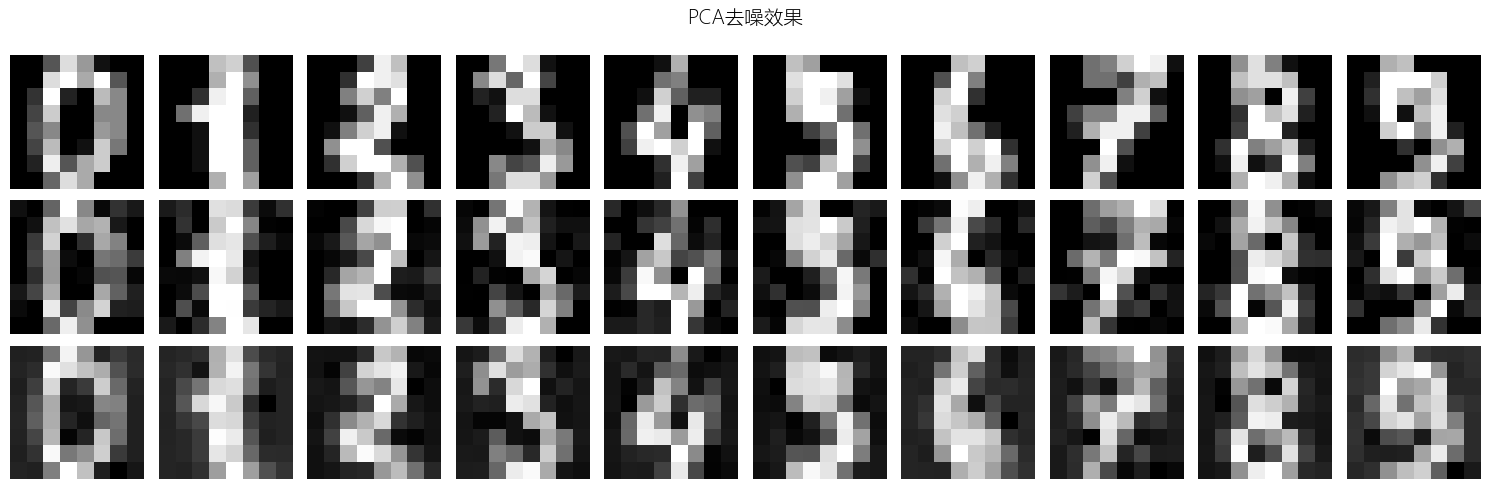

In [18]:
# PCA去噪演示
# 固定随机种子，保证每次运行生成的噪声一致
np.random.seed(42)
# 调大噪声系数，增强噪声视觉效果
noise_factor = 2.0
# 给原始手写数字数据叠加高斯噪声
X_digits_noisy = X_digits + noise_factor * np.random.normal(size=X_digits.shape)
# 限制像素值范围：手写数字像素取值为 0~16，防止数值越界
X_digits_noisy = np.clip(X_digits_noisy, 0, 16)

# 初始化PCA：按累计方差90%自动选择主成分，过滤低信息噪声成分
pca_denoise = PCA(n_components=0.90)
# 第一步：降维，保留有效信息主成分、舍弃噪声成分
X_digits_denoised = pca_denoise.fit_transform(X_digits_noisy)
# 第二步：逆变换，从低维主成分还原回原始64维特征，完成去噪
X_digits_denoised = pca_denoise.inverse_transform(X_digits_denoised)

# 创建画布：3行10列子图，分别存放原图、加噪图、去噪图
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

# 循环遍历前10张手写数字样本（0~9）
for i in range(10):
    # 第一行：绘制原始图像，64维特征重塑为8×8像素图，灰度图展示
    axes[0, i].imshow(X_digits[i].reshape(8, 8), cmap='gray')
    axes[0, i].axis('off')  # 隐藏坐标轴
    # 仅第一列添加行标签
    if i == 0:
        axes[0, i].set_ylabel('原始', rotation=0, ha='right', fontsize=12)
    
    # 第二行：绘制添加噪声后的图像
    axes[1, i].imshow(X_digits_noisy[i].reshape(8, 8), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('加噪', rotation=0, ha='right', fontsize=12)
    
    # 第三行：绘制PCA去噪后的图像
    axes[2, i].imshow(X_digits_denoised[i].reshape(8, 8), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('去噪', rotation=0, ha='right', fontsize=12)

# 设置整张图的总标题
plt.suptitle('PCA去噪效果', fontsize=14)
# 自动调整子图间距
plt.tight_layout()
# 展示图像
plt.show()

---

## 七、PCA用于加速机器学习

下面我们做一个对比实验，量化评估 PCA 降维对机器学习模型（随机森林）在训练效率、预测速度和分类精度上的实际影响。

这段代码主要做3件事情：
1. 数据预处理与划分（注意标准化处理）
2. 双模型对比
   - 方法 1（原始特征）：直接将 64 维的标准化数据输入随机森林模型，记录其训练时间、预测时间和测试准确率作为基准。
   - 方法 2（PCA 降维）：先使用 PCA 将数据降至保留 90% 方差的维度，再输入随机森林模型，同样记录各项性能指标。
3. 性能量化对比，直观对比两种方法在四个关键指标上的差异：
   - 维度压缩：直观展示原始 64 维被压缩到了多少维。
   - 时间收益：计算并展示训练时间和预测时间的缩短百分比。
   - 精度代价：计算并展示准确率下降的百分比。

In [19]:
print("PCA加速机器学习")

# 划分训练集、测试集
# test_size=0.2：20%作为测试集，80%作为训练集
# random_state=42：固定随机种子，保证每次划分结果一致
# stratify=y_digits：按标签分层抽样，保证训练/测试集类别分布和原数据一致
X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits)

# 数据标准化：统一特征尺度，消除量纲影响
scaler = StandardScaler()
# 用训练集拟合标准化规则，并转换训练集
X_train_scaled = scaler.fit_transform(X_train)
# 仅用已有规则转换测试集（不重新拟合，避免数据泄露）
X_test_scaled = scaler.transform(X_test)

# 导入时间模块，用于统计运行耗时
import time

# ===================== 方法1：使用原始64维特征建模 =====================
print("\n方法1: 原始特征 (64维)")
print("-" * 40)

# 记录训练开始时间
start_time = time.time()
# 初始化随机森林分类器
# n_estimators=100：100棵决策树
# n_jobs=-1：使用全部CPU核心并行运算
rf_original = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# 模型训练
rf_original.fit(X_train_scaled, y_train)
# 计算训练总耗时
train_time_original = time.time() - start_time

# 记录预测开始时间
start_time = time.time()
# 测试集预测
pred_original = rf_original.predict(X_test_scaled)
# 计算预测耗时
predict_time_original = time.time() - start_time

# 计算分类准确率
acc_original = accuracy_score(y_test, pred_original)

# 打印原始特征下的各项指标
print(f"训练时间: {train_time_original:.3f}秒")
print(f"预测时间: {predict_time_original:.3f}秒")
print(f"测试准确率: {acc_original:.4f}")

# ===================== 方法2：PCA降维后再建模 =====================
print("\n方法2: PCA降维 (保留90%方差)")
print("-" * 40)

# 初始化PCA，自动保留累计方差90%的主成分
pca_transform = PCA(n_components=0.90)
# 训练集拟合PCA并完成降维
X_train_pca = pca_transform.fit_transform(X_train_scaled)
# 测试集使用训练好的PCA规则降维
X_test_pca = pca_transform.transform(X_test_scaled)

# 输出降维后的特征维度
print(f"降维后维度: {X_train_pca.shape[1]}")

# 计时 + 训练随机森林
start_time = time.time()
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
train_time_pca = time.time() - start_time

# 计时 + 测试集预测
start_time = time.time()
pred_pca = rf_pca.predict(X_test_pca)
predict_time_pca = time.time() - start_time

# 计算降维后的准确率
acc_pca = accuracy_score(y_test, pred_pca)

# 打印降维后各项指标
print(f"训练时间: {train_time_pca:.3f}秒")
print(f"预测时间: {predict_time_pca:.3f}秒")
print(f"测试准确率: {acc_pca:.4f}")

# ===================== 两类结果汇总对比 =====================
print("\n性能对比:")
print("=" * 40)
# 表头：格式化对齐输出
print(f"{'指标':<20} {'原始':<15} {'PCA':<15} {'变化':<15}")
print("-" * 65)

# 维度对比：原始64维 vs 降维后维度，标注减少的维度数
print(f"{'维度':<20} {64:<15} {X_train_pca.shape[1]:<15} {'↓' + str(64-X_train_pca.shape[1]):<15}")

# 训练时间对比，计算耗时下降百分比
print(f"{'训练时间(秒)':<20} {train_time_original:<15.3f} {train_time_pca:<15.3f} {'↓' + f'{(1-train_time_pca/train_time_original)*100:.0f}%':<15}")

# 预测时间对比，计算耗时下降百分比
print(f"{'预测时间(秒)':<20} {predict_time_original:<15.3f} {predict_time_pca:<15.3f} {'↓' + f'{(1-predict_time_pca/predict_time_original)*100:.0f}%':<15}")

# 准确率对比，计算精度下降百分点
print(f"{'准确率':<20} {acc_original:<15.4f} {acc_pca:<15.4f} {'↓' + f'{(acc_original-acc_pca)*100:.1f}%':<15}")

PCA加速机器学习

方法1: 原始特征 (64维)
----------------------------------------
训练时间: 0.252秒
预测时间: 0.044秒
测试准确率: 0.9639

方法2: PCA降维 (保留90%方差)
----------------------------------------
降维后维度: 31
训练时间: 0.221秒
预测时间: 0.043秒
测试准确率: 0.9500

性能对比:
指标                   原始              PCA             变化             
-----------------------------------------------------------------
维度                   64              31              ↓33            
训练时间(秒)              0.252           0.221           ↓12%           
预测时间(秒)              0.044           0.043           ↓3%            
准确率                  0.9639          0.9500          ↓1.4%          


从输出结果可以看到，维度减少了一大半，训练时间减少了12%,准确率只下降1.4%，验证了 PCA 在实际工程中的核心价值：以极小的精度损失为代价，大幅降低特征维度，从而显著提升模型的训练和预测速度。

---

## 八、PCA参数详解与注意事项

来详细看看每个参数的用法：

**1. n_components: 保留的主成分数**
  - int: 指定保留几个主成分
  - float (0-1): 指定保留多少方差比例
  - None: 保留所有主成分
  - 'mle': 用最大似然估计自动选择

**2. whiten: 是否白化**
  - False: 默认，只旋转数据
  - True: 额外缩放，使各主成分方差为1
  - 用途: 某些算法（如神经网络）需要白化数据

**3. svd_solver: SVD求解方法**
  - 'auto': 根据数据自动选择
  - 'full': 完整SVD，适合小数据
  - 'arpack': 随机SVD，适合大数据
  - 'randomized': 随机化算法，最快

**4. random_state: 随机种子**
  - 只在svd_solver='arpack'或'randomized'时使用


**PCA使用注意事项:**

**必须标准化！**
   PCA对特征尺度敏感，大尺度特征会主导主成分

**先标准化，再PCA**
   scaler = StandardScaler()
   X_scaled = scaler.fit_transform(X)
   X_pca = PCA().fit_transform(X_scaled)

**PCA是线性变换**
   不能捕捉非线性结构
   非线性降维用t-SNE、UMAP

**PCA会丢失信息**
   降维后无法完全恢复原始数据
   保留足够主成分以保留主要信息


下面我们画图对比一下标准化处理对 PCA（主成分分析）降维结果的影响。

四张子图分工

- 左上 / 右上：分别画出「原始数据 PCA」和「标准化后 PCA」的二维聚类分布，观察类别区分效果；
- 左下：对比两组数据第一主成分的信息占比；
- 右下：绘制完整累计方差曲线，对比达到相同信息保留率（如 95%）所需的主成分数量。

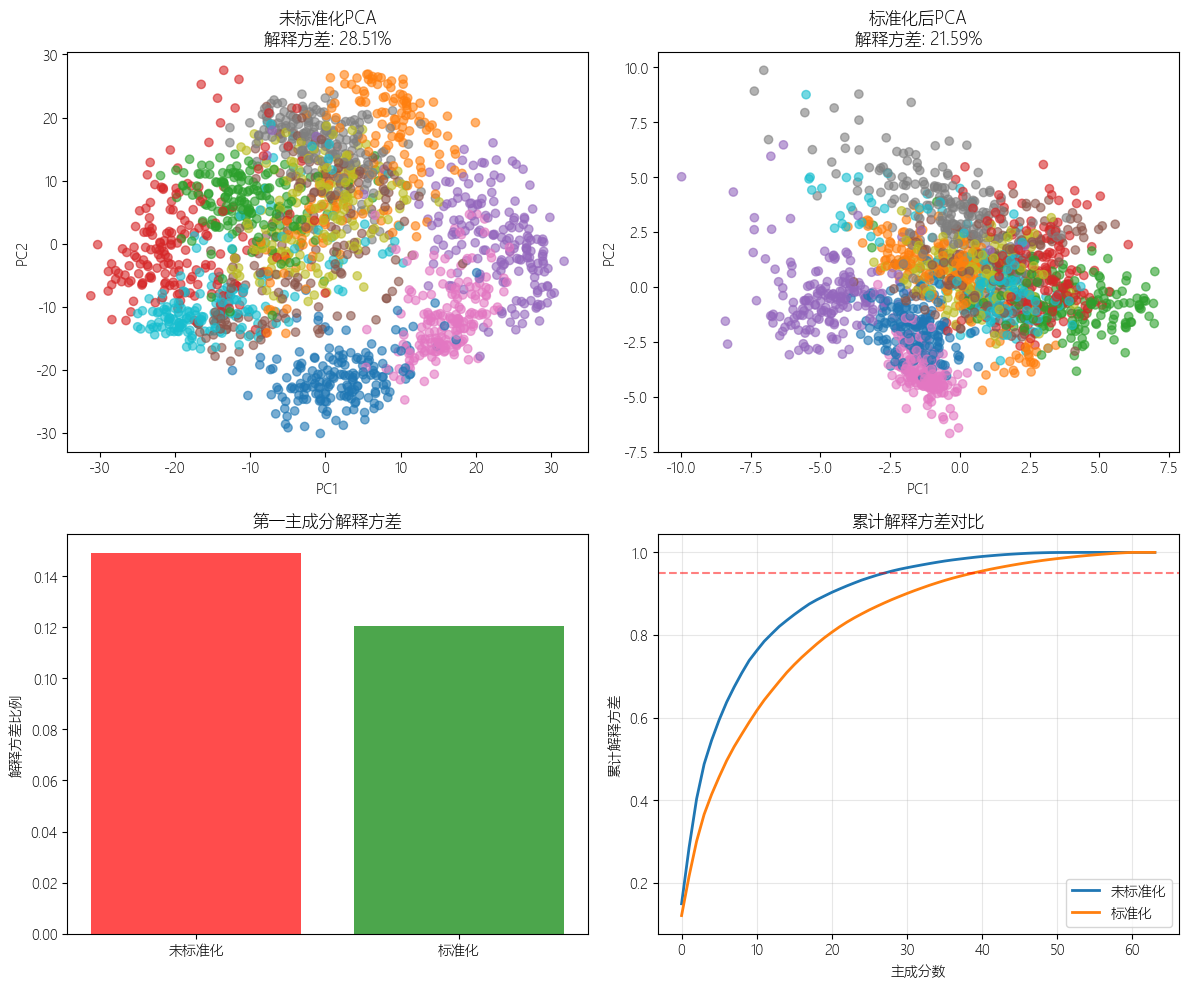

In [24]:
# 对比标准化前后的PCA效果
# 创建 2行2列 画布，整体尺寸 12×10
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ========== 左上：未做标准化的PCA（降至2维） ==========
# 初始化PCA，保留前2个主成分
pca_raw = PCA(n_components=2)
# 直接使用原始手写数字数据做PCA变换
X_pca_raw = pca_raw.fit_transform(X_digits)

# 绘制降维后散点图，用真实标签区分颜色
axes[0, 0].scatter(X_pca_raw[:, 0], X_pca_raw[:, 1], c=y_digits, cmap='tab10', alpha=0.6)
# 标题：标注是否标准化 + 前两主成分累计方差解释率
axes[0, 0].set_title(f'未标准化PCA\n解释方差: {pca_raw.explained_variance_ratio_.sum():.2%}')
axes[0, 0].set_xlabel('PC1')  # X轴：第一主成分
axes[0, 0].set_ylabel('PC2')  # Y轴：第二主成分

# ========== 右上：标准化后的PCA（降至2维） ==========
# 绘制标准化+PCA降维后的散点（依赖前文已算出的 X_digits_2d、pca_2d）
axes[0, 1].scatter(X_digits_2d[:, 0], X_digits_2d[:, 1], c=y_digits, cmap='tab10', alpha=0.6)
# 标题：标注标准化状态 + 累计方差解释率
axes[0, 1].set_title(f'标准化后PCA\n解释方差: {pca_2d.explained_variance_ratio_.sum():.2%}')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')

# ========== 左下：第一主成分 单方差解释率对比 ==========
# 柱状图对比两组数据第一个主成分的信息占比
axes[1, 0].bar(
    ['未标准化', '标准化'],
    [pca_raw.explained_variance_ratio_[0], pca_2d.explained_variance_ratio_[0]],
    color=['red', 'green'], alpha=0.7
)
axes[1, 0].set_title('第一主成分解释方差')
axes[1, 0].set_ylabel('解释方差比例')

# ========== 右下：全量主成分 累计方差曲线对比 ==========
# 不指定维度，训练完整PCA（保留全部主成分）
pca_raw_full = PCA().fit(X_digits)
pca_scaled_full = PCA().fit(X_digits_scaled)

# 绘制未标准化数据的累计方差曲线
axes[1, 1].plot(np.cumsum(pca_raw_full.explained_variance_ratio_), 
               label='未标准化', linewidth=2)
# 绘制标准化数据的累计方差曲线
axes[1, 1].plot(np.cumsum(pca_scaled_full.explained_variance_ratio_), 
               label='标准化', linewidth=2)
# 绘制95%方差参考虚线
axes[1, 1].axhline(y=0.95, color='r', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('主成分数')
axes[1, 1].set_ylabel('累计解释方差')
axes[1, 1].set_title('累计解释方差对比')
axes[1, 1].legend()   # 显示图例
axes[1, 1].grid(True, alpha=0.3)  # 显示网格

plt.tight_layout()
plt.show()

未标准化时的方差解释率高于标准化后的方差解释率，说明如果不进行标准化，PCA 会错误地赋予高方差特征过高的权重，导致降维结果严重失真；标准化后各特征尺度统一，PCA 能公平挖掘真实数据结构，聚类、方差分布都更合理。

---

## 九、综合实战：鸢尾花数据降维与分类

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：

先用PCA降维到2D和3D：

In [22]:
print("综合实战：鸢尾花数据降维分析")

# 加载鸢尾花数据
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

print(f"鸢尾花数据:")
print(f"  样本数: {X_iris.shape[0]}")
print(f"  特征数: {X_iris.shape[1]} ({', '.join(iris.feature_names)})")
print(f"  类别: {', '.join(iris.target_names)}")

# 标准化
X_iris_scaled = StandardScaler().fit_transform(X_iris)

# PCA降维到2D和3D
pca_iris_2d = PCA(n_components=2)
X_iris_2d = pca_iris_2d.fit_transform(X_iris_scaled)

pca_iris_3d = PCA(n_components=3)
X_iris_3d = pca_iris_3d.fit_transform(X_iris_scaled)

print(f"\n降维结果:")
print(f"  2D PCA解释方差: {pca_iris_2d.explained_variance_ratio_.sum():.2%}")
print(f"  3D PCA解释方差: {pca_iris_3d.explained_variance_ratio_.sum():.2%}")


综合实战：鸢尾花数据降维分析
鸢尾花数据:
  样本数: 150
  特征数: 4 (sepal length (cm), sepal width (cm), petal length (cm), petal width (cm))
  类别: setosa, versicolor, virginica

降维结果:
  2D PCA解释方差: 95.81%
  3D PCA解释方差: 99.48%


降维结果有了，画图看看不同维度的投影效果：


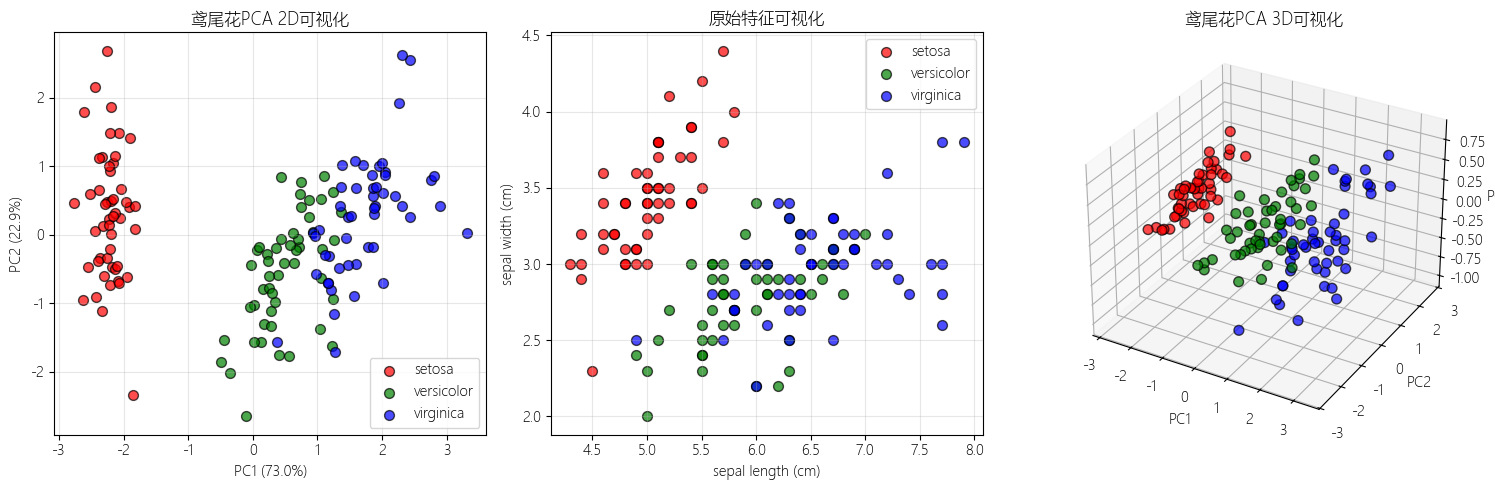


主成分与原始特征的关系:
----------------------------------------
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1              0.521            -0.269              0.580             0.565
PC2              0.377             0.923              0.024             0.067

解读:
  PC1主要与花瓣长度、花瓣宽度正相关
  PC2主要与花萼长度、花萼宽度有关


In [23]:
# 可视化
fig = plt.figure(figsize=(15, 5))

# 2D可视化
ax1 = fig.add_subplot(131)
colors = ['red', 'green', 'blue']
for i, target_name in enumerate(iris.target_names):
    ax1.scatter(X_iris_2d[y_iris == i, 0], X_iris_2d[y_iris == i, 1],
               c=colors[i], label=target_name, alpha=0.7, s=50, edgecolors='k')
ax1.set_xlabel(f'PC1 ({pca_iris_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_iris_2d.explained_variance_ratio_[1]:.1%})')
ax1.set_title('鸢尾花PCA 2D可视化')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 原始特征对比（前两个特征）
ax2 = fig.add_subplot(132)
for i, target_name in enumerate(iris.target_names):
    ax2.scatter(X_iris[y_iris == i, 0], X_iris[y_iris == i, 1],
               c=colors[i], label=target_name, alpha=0.7, s=50, edgecolors='k')
ax2.set_xlabel(iris.feature_names[0])
ax2.set_ylabel(iris.feature_names[1])
ax2.set_title('原始特征可视化')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3D可视化
ax3 = fig.add_subplot(133, projection='3d')
for i, target_name in enumerate(iris.target_names):
    ax3.scatter(X_iris_3d[y_iris == i, 0], X_iris_3d[y_iris == i, 1], X_iris_3d[y_iris == i, 2],
               c=colors[i], label=target_name, alpha=0.7, s=50, edgecolors='k')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')
ax3.set_title('鸢尾花PCA 3D可视化')

plt.tight_layout()
plt.show()

# 主成分与原始特征的关系
print(f"\n主成分与原始特征的关系:")
print("-" * 40)
components_df = pd.DataFrame(
    pca_iris_2d.components_,
    columns=iris.feature_names,
    index=['PC1', 'PC2']
)
print(components_df.round(3))

print(f"\n解读:")
print(f"  PC1主要与花瓣长度、花瓣宽度正相关")
print(f"  PC2主要与花萼长度、花萼宽度有关")


---

## 十、PCA vs 其他降维方法

| 方法 | 特点 |
| --- | --- |
| PCA | 线性、无监督、保留全局结构、计算快 |
| t-SNE | 非线性、无监督、保留局部结构、适合可视化 |
| UMAP | 非线性、无监督、保留局部+全局结构、计算快 |
| LDA | 线性、有监督、最大化类间距离 |
| Autoencoder | 非线性、神经网络、可深度学习 |

选择建议：
• 快速降维/预处理 → PCA
• 可视化高维数据 → t-SNE或UMAP
• 有标签的分类任务 → LDA
• 深度学习场景 → Autoencoder


---

## 十一、小结

| 概念 | 说明 |
|------|------|
| **主成分** | 数据方差最大的方向 |
| **解释方差** | 主成分保留的原始信息量 |
| **降维** | 用较少维度表示原始数据 |
| **标准化** | PCA的必要预处理步骤 |

**PCA使用步骤**：
1. 标准化数据（必须！）
2. 拟合PCA，查看解释方差
3. 确定保留的主成分数
4. 转换数据
5. 在降维后的数据上建模/可视化

---

## 十二、课后练习

1. 对一份高维数据集进行PCA，画出碎石图（scree plot）
2. 比较保留不同比例方差（80%、90%、95%）对分类准确率的影响
3. 用PCA对一张彩色图片进行颜色降维
4. 思考：PCA和特征选择有什么区别？

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 57 篇：XGBoost — 集成学习从原理到实战**
>
> 下篇学 XGBoost——Kaggle 竞赛中最常用的算法，梯度提升的集大成者，数据科学比赛的「大杀器」。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*
